In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt

from waffles.input_output.hdf5_structured import load_structured_waveformset
from waffles.data_classes.Waveform import Waveform
from waffles.data_classes.WaveformSet import WaveformSet
# from waffles.data_classes.BasicWfAna import BasicWfAna
# from waffles.data_classes.IPDict import IPDict
from waffles.data_classes.UniqueChannel import UniqueChannel
from waffles.data_classes.ChannelWsGrid import ChannelWsGrid
from waffles.utils.denoising.tv1ddenoise import Denoise
from waffles.np02_utils.AutoMap import generate_ChannelMap, dict_uniqch_to_module, dict_module_to_uniqch, ordered_modules_pmt, strUch, getModuleName
from waffles.np02_utils.PlotUtils import plot_detectors, runBasicWfAnaNP02, runBasicWfAnaNP02Updating, matplotlib_plot_WaveformSetGrid
from waffles.np02_utils.load_utils import open_processed

In [2]:
dettype = 'pmt'
run=43363
nwaveforms=None
mergefiles=True
wfset_full = open_processed(run,dettype=dettype, datadir="/eos/experiment/neutplatform/protodune/experiments/ProtoDUNE-VD/commissioning/", nwaveforms=nwaveforms, mergefiles=mergefiles)


List of files found:
['/eos/experiment/neutplatform/protodune/experiments/ProtoDUNE-VD/commissioning//processed/run043363_pmt/processed_np02vd_raw_run043363_0000_df-s04-d0_dw_0_20260319T161820.hdf5_structured_pmt.hdf5', '/eos/experiment/neutplatform/protodune/experiments/ProtoDUNE-VD/commissioning//processed/run043363_pmt/processed_np02vd_raw_run043363_0001_df-s04-d0_dw_0_20260319T161933.hdf5_structured_pmt.hdf5', '/eos/experiment/neutplatform/protodune/experiments/ProtoDUNE-VD/commissioning//processed/run043363_pmt/processed_np02vd_raw_run043363_0002_df-s04-d0_dw_0_20260319T162045.hdf5_structured_pmt.hdf5']
📤 load_structured_waveformset returning type: <class 'waffles.data_classes.WaveformSet.WaveformSet'> with 548051 waveforms
📤 load_structured_waveformset returning type: <class 'waffles.data_classes.WaveformSet.WaveformSet'> with 547530 waveforms
📤 load_structured_waveformset returning type: <class 'waffles.data_classes.WaveformSet.WaveformSet'> with 547575 waveforms


313523 -389821 0.011253504000000001


Text(0.5, 0, 'daq_window_timestamp - timestamp [ticks]')

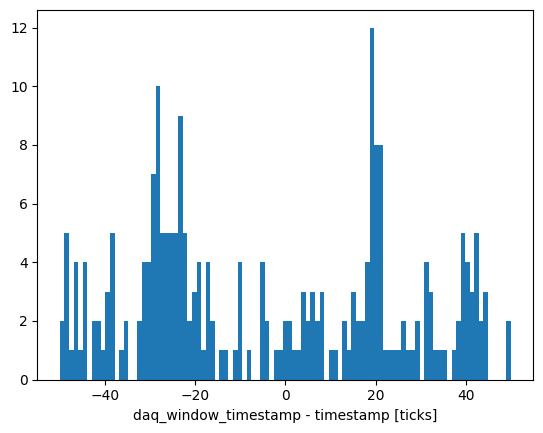

In [3]:
diffvalues = [ wf.daq_window_timestamp - wf.timestamp for wf in wfset_full.waveforms  ]
dmax = np.max(diffvalues)
dmin = np.min(diffvalues)
print(dmax, dmin, (dmax-dmin)*16e-9)
hc, hbins, _ = plt.hist(diffvalues, bins=np.linspace(-50, 50, 100));
plt.xlabel("daq_window_timestamp - timestamp [ticks]")

In [4]:
def adjust_offset(waveform:Waveform) -> bool:
    if -5 < waveform.daq_window_timestamp - waveform.timestamp < 25:
        return True
    return True

# def adjust_offset(waveform: Waveform) -> bool:
#     return -5 < waveform.daq_window_timestamp - waveform.timestamp < 25
    
wfset_triggered_all = WaveformSet.from_filtered_WaveformSet(wfset_full, adjust_offset, show_progress=True)
wfset_triggered_all

  0%|          | 0/1643156 [00:00<?, ?it/s]

100%|██████████| 1643156/1643156 [00:01<00:00, 943776.89it/s] 


WaveformSet with 1643156 waveforms runs: [43363], points_per_wf: 1024, available_channels: {43363: {110: {0, 2, 6, 7, 10, 12, 14, 16, 17, 20, 22, 24, 26, 30, 32, 34, 36, 37, 40, 42, 44, 46}}}, record_numbers per run: run 43363: 4327 records

In [5]:
runBasicWfAnaNP02(wfset_triggered_all, baselinefinish=65, onlyoptimal=True, threshold=25)

Processing waveform set with BasicWfAna


100%|██████████| 1643156/1643156 [08:00<00:00, 3420.57it/s]


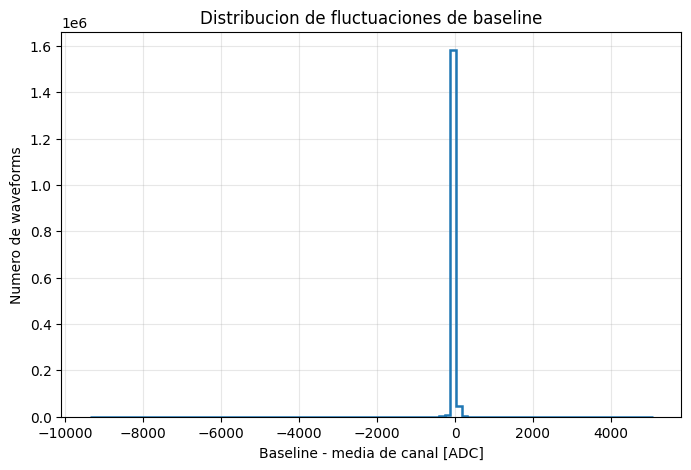

In [6]:
# Analizar la distribución de fluctuaciones de baseline

from collections import defaultdict
analysis_label = "std"

# 1. Guardar baselines por canal
baselines_by_channel = defaultdict(list)

for wf in wfset_triggered_all.waveforms:
    ep = wf.endpoint
    ch = wf.channel
    baseline = wf.analyses[analysis_label].result["baseline"]

    baselines_by_channel[(ep, ch)].append(baseline)

# 2. Calcular la baseline media de cada canal
mean_baseline_by_channel = {
    channel: np.mean(baselines)
    for channel, baselines in baselines_by_channel.items()
}

# 3. Calcular baseline - media de canal para cada waveform
baseline_residuals = []

for wf in wfset_triggered_all.waveforms:
    ep = wf.endpoint
    ch = wf.channel
    baseline = wf.analyses[analysis_label].result["baseline"]
    channel_mean = mean_baseline_by_channel[(ep, ch)]

    baseline_residuals.append(baseline - channel_mean)

baseline_residuals = np.array(baseline_residuals)

# 4. Histograma
# x_range = (-400, 400)   # Ajusta según el rango esperado de fluctuaciones

plt.figure(figsize=(8, 5))
# plt.hist(baseline_residuals, bins=100, range=x_range, histtype="step", linewidth=1.8)   # Agrega el rango para limitar el eje x
plt.hist(baseline_residuals, bins=100, histtype="step", linewidth=1.8)
# plt.xlim(x_range)

plt.xlabel("Baseline - media de canal [ADC]")
plt.ylabel("Numero de waveforms")
plt.title("Distribucion de fluctuaciones de baseline")
plt.grid(alpha=0.3)
plt.show()

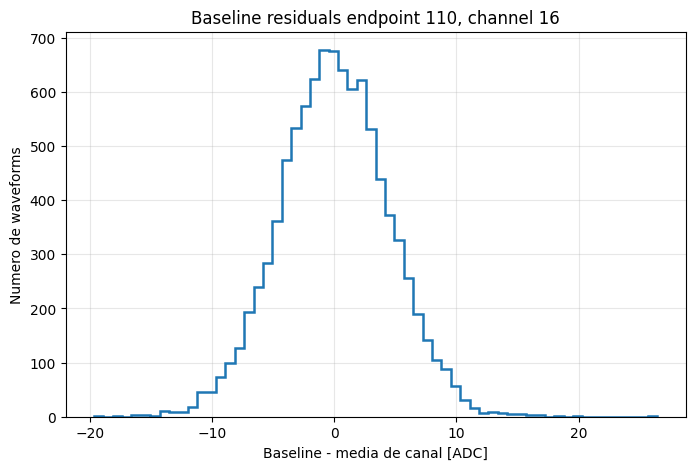

In [7]:
# Analizar la distribución de fluctuaciones de baseline para un canal específico

target_ep = 110
target_ch = 16

residuals_ch = []

for wf in wfset_triggered_all.waveforms:
    if wf.endpoint == target_ep and wf.channel == target_ch:
        baseline = wf.analyses["std"].result["baseline"]
        channel_mean = mean_baseline_by_channel[(target_ep, target_ch)]
        residuals_ch.append(baseline - channel_mean)

# Histograma

plt.figure(figsize=(8, 5))
plt.hist(residuals_ch, bins=60, histtype="step", linewidth=1.8)

plt.xlabel("Baseline - media de canal [ADC]")
plt.ylabel("Numero de waveforms")
plt.title(f"Baseline residuals endpoint {target_ep}, channel {target_ch}")
plt.grid(alpha=0.3)
plt.show()

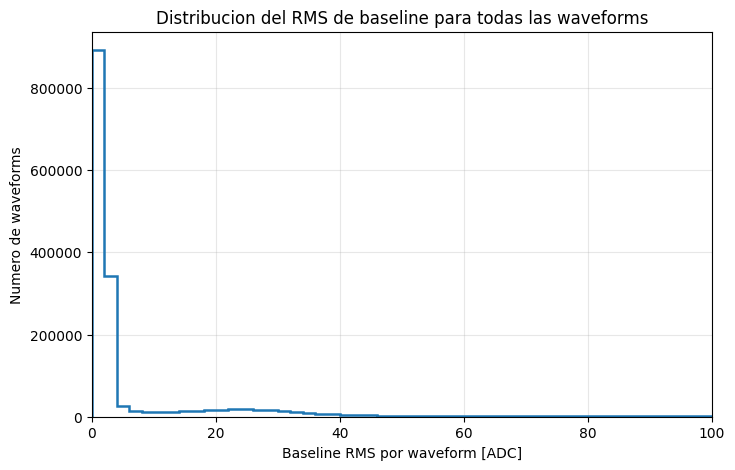

In [8]:
# RMS distribution of the baseline for all waveforms and all channels

baseline_start = 0
baseline_finish = 65
analysis_label = "std"
x_range = (0, 100)

baseline_rms_values = []

for wf in wfset_triggered_all.waveforms:
    baseline = wf.analyses[analysis_label].result["baseline"]

    baseline_region = wf.adcs[baseline_start:baseline_finish] - baseline

    baseline_rms = np.sqrt(np.mean(baseline_region**2))
    baseline_rms_values.append(baseline_rms)

baseline_rms_values = np.array(baseline_rms_values)

plt.figure(figsize=(8, 5))
plt.hist(baseline_rms_values, bins=50, range=x_range, histtype="step", linewidth=1.8)
plt.xlim(x_range)

plt.xlabel("Baseline RMS por waveform [ADC]")
plt.ylabel("Numero de waveforms")
plt.title("Distribucion del RMS de baseline para todas las waveforms")
plt.grid(alpha=0.3)
plt.show()


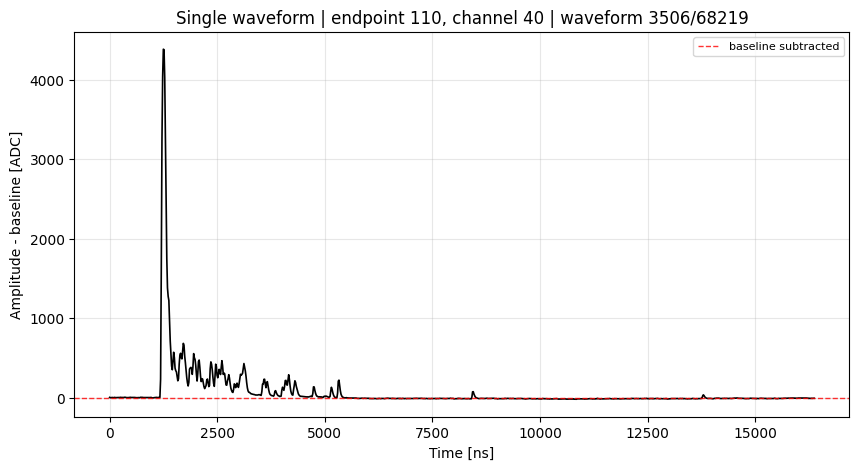

In [9]:
# Plotear una waveform seleccionada de un canal

# Controles de usuario: elige el canal y que waveform de ese canal quieres dibujar.
selected_endpoint = 110
selected_channel = 40
waveform_index = 3506
analysis_label = "std"
subtract_baseline = True


# Quedarse solo con las waveforms que pertenecen al canal electronico seleccionado.
def select_selected_channel(wf):
    return wf.endpoint == selected_endpoint and wf.channel == selected_channel

# Crear un nuevo waveform set solo con las waveforms del canal seleccionado.
wfset_selected_channel = WaveformSet.from_filtered_WaveformSet(
    wfset_triggered_all,
    select_selected_channel,
    show_progress=False,
)

# Lanzar un error claro si el canal o el indice seleccionados no existen en este waveform set.
if len(wfset_selected_channel.waveforms) == 0:
    raise ValueError(f"No waveforms found for endpoint {selected_endpoint}, channel {selected_channel}")

if waveform_index >= len(wfset_selected_channel.waveforms):
    raise IndexError(
        f"waveform_index={waveform_index} but only "
        f"{len(wfset_selected_channel.waveforms)} waveforms are available"
    )

# Extraer la waveform pedida y su baseline calculada por runBasicWfAnaNP02.
wf = wfset_selected_channel.waveforms[waveform_index]
baseline = wf.analyses[analysis_label].result["baseline"]

# Plotear los ADCs crudos o los ADCs tras restar la baseline de esa waveform.
y_raw = wf.adcs
y_plot = y_raw - baseline if subtract_baseline else y_raw

# Convertir ticks a tiempo usando el periodo de muestreo de los PMTs: 1 tick = 16 ns.
ticks = np.arange(len(y_plot))
times_ns = ticks * 16

plt.figure(figsize=(10, 5))
plt.plot(times_ns, y_plot, color="black", linewidth=1.2)

if subtract_baseline:
    plt.axhline(0, color="red", linestyle="--", linewidth=1, alpha=0.8, label="baseline subtracted")
    plt.ylabel("Amplitude - baseline [ADC]")
else:
    plt.axhline(baseline, color="red", linestyle="--", linewidth=1, alpha=0.8, label=f"baseline = {baseline:.2f} ADC")
    plt.ylabel("Amplitude [ADC]")

plt.xlabel("Time [ns]")
plt.title(
    f"Single waveform | endpoint {selected_endpoint}, channel {selected_channel} | "
    f"waveform {waveform_index}/{len(wfset_selected_channel.waveforms)-1}"
)
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.show()



# Visor de las waveforms mas anomalas de un canal

In [10]:
# # Visor de las waveforms mas anomalas de un canal

# from ipywidgets import interact, IntSlider
# import time

# # Controles principales: cambia aqui el canal que quieres inspeccionar.
# selected_endpoint = 110
# selected_channel = 14
# analysis_label = "std"

# # Se analizan todas las waveforms disponibles del canal seleccionado.
# n_anomalous_to_keep_all = 10000


# # Ventanas usadas para calcular metricas basicas.
# baseline_window = slice(0, 65)
# peak_window = slice(60, 100)
# integral_window = slice(60, 160)

# t0 = time.time()

# # Seleccionar todas las waveforms del canal.
# selected_waveforms_all = []
# for scanned_idx, wf in enumerate(wfset_triggered_all.waveforms, start=1):

#     if wf.endpoint == selected_endpoint and wf.channel == selected_channel:
#         selected_waveforms_all.append(wf)




# if len(selected_waveforms_all) == 0:
#     raise ValueError(f"No waveforms found for endpoint {selected_endpoint}, channel {selected_channel}")

# # Calcular metricas simples solo para las waveforms seleccionadas.
# metrics = []

# for idx, wf in enumerate(selected_waveforms_all):

#     if analysis_label not in wf.analyses:
#         raise RuntimeError(f"Waveform idx={idx} no tiene analisis '{analysis_label}'. Ejecuta runBasicWfAnaNP02 primero.")

#     baseline = wf.analyses[analysis_label].result["baseline"]
#     y = wf.adcs - baseline

#     pre_rms = np.std(y[baseline_window])
#     peak_rel_idx = np.argmax(y[peak_window])
#     peak_tick = peak_window.start + peak_rel_idx
#     peak_amp = y[peak_tick]
#     integral = np.sum(y[integral_window])

#     metrics.append({
#         "idx": idx,
#         "baseline": baseline,
#         "pre_rms": pre_rms,
#         "peak_tick": peak_tick,
#         "peak_amp": peak_amp,
#         "integral": integral,
#     })

# metrics = np.array(metrics, dtype=object)

# # Z-score robusto usando mediana y MAD, menos sensible a outliers que media/std.
# def robust_z(values):
#     values = np.asarray(values, dtype=float)
#     median = np.median(values)
#     mad = np.median(np.abs(values - median))
#     scale = 1.4826 * mad

#     if scale == 0:
#         scale = np.std(values)
#     if scale == 0:
#         return np.zeros_like(values)

#     return (values - median) / scale


# pre_rms_values = np.array([m["pre_rms"] for m in metrics])
# peak_tick_values = np.array([m["peak_tick"] for m in metrics])
# peak_amp_values = np.array([m["peak_amp"] for m in metrics])
# integral_values = np.array([m["integral"] for m in metrics])

# # Score grande = waveform mas rara respecto al comportamiento tipico del canal.
# anomaly_scores = np.sqrt(
#     robust_z(pre_rms_values)**2
#     + robust_z(peak_tick_values)**2
#     + robust_z(peak_amp_values)**2
#     + robust_z(integral_values)**2
# )

# for m, score in zip(metrics, anomaly_scores):
#     m["anomaly_score"] = score

# n_to_show_all = min(n_anomalous_to_keep_all, len(selected_waveforms_all))
# anomaly_order_all = np.argsort(anomaly_scores)[::-1][:n_to_show_all]

# print(f"Waveforms analizadas: {len(selected_waveforms_all)}")
# print(f"Waveforms mostrables en el slider: {n_to_show_all}")
# print(f"Preparacion terminada en {time.time() - t0:.2f} s")


# def plot_anomalous_waveform_all(anomaly_rank=0):
#     actual_idx = anomaly_order_all[anomaly_rank]
#     wf = selected_waveforms_all[actual_idx]
#     m = metrics[actual_idx]

#     baseline = wf.analyses[analysis_label].result["baseline"]
#     y = wf.adcs - baseline

#     ticks = np.arange(len(y))
#     times_ns = ticks * 16

#     plt.figure(figsize=(11, 5))
#     plt.plot(times_ns, y, color="black", linewidth=1.0, alpha=0.85, label="Selected waveform")
#     plt.axvline(m["peak_tick"] * 16, color="tab:red", linestyle="--", linewidth=1.0, alpha=0.8, label="Peak tick")
#     plt.axhline(0, color="gray", linestyle=":", linewidth=1.0)

#     info_text = (
#         f"anomaly rank = {anomaly_rank} / {n_to_show_all - 1}\n"
#         f"waveform index in scan = {actual_idx}\n"
#         f"baseline = {m['baseline']:.2f} ADC\n"
#         f"pre-RMS = {m['pre_rms']:.2f} ADC\n"
#         f"peak = {m['peak_amp']:.2f} ADC at tick {m['peak_tick']}\n"
#         f"integral = {m['integral']:.2f} ADC*tick\n"
#         f"anomaly score = {m['anomaly_score']:.2f}"
#     )

#     plt.gca().text(
#         0.02,
#         0.98,
#         info_text,
#         transform=plt.gca().transAxes,
#         va="bottom",
#         ha="right",
#         fontsize=9,
#         bbox=dict(facecolor="white", alpha=0.85, edgecolor="lightgray"),
#     )

#     plt.xlabel("Time [ns]")
#     plt.ylabel("Amplitude - baseline [ADC]")
#     plt.title(f"All waveforms | Endpoint {selected_endpoint}, channel {selected_channel}")
#     plt.legend(fontsize=8, loc="upper right")
#     plt.grid(alpha=0.3)
#     plt.show()


# interact(
#     plot_anomalous_waveform_all,
#     anomaly_rank=IntSlider(
#         min=0,
#         max=n_to_show_all - 1,
#         step=1,
#         value=0,
#         description="rank",
#         continuous_update=False,
#     ),
# )


In [11]:
# argsheat = dict(
#     mode="heatmap",
#     analysis_label="std",
#     adc_range_above_baseline=1000,
#     adc_range_below_baseline=-250,
#     adc_bins=400,
#     time_bins=wfset_full.points_per_wf//2,
#     filtering=4,
#     share_y_scale=True,
#     share_x_scale=True,
#     wfs_per_axes=5000,
#     zlog=True,
#     width=1600,
#     height=1200
# )
# # detector=[ UniqueChannel(110, ch) for ch in wfch[110].keys() ]
# detector = ordered_modules_pmt
# group1 = detector[:len(detector)//2]
# group2 = detector[len(detector)//2:]
# plot_detectors(wfset_triggered_all, detector, **argsheat)

## Filtros de calidad para preparar la waveform promedio

Estas celdas construyen una seleccion limpia a partir de `wfset_triggered_all`, antes del filtro final de amplitud y antes de calcular las waveforms promedio. La idea es medir, por waveform y por canal, cantidades que identifican eventos malos: ruido en baseline, actividad pre-trigger, amplitud anomala, tiempo de pico desplazado, carga rara y saturacion.

El resultado principal es `wfset_quality`. Tambien quedan guardadas las razones de rechazo en `quality_reasons_by_wf_id`, para poder depurar que filtro esta descartando cada evento.

| Corte | Descripción | Condición de rechazo | Razón |
|------|-------------|----------------------|--------|
| `baseline_nmad` | Baseline anómala respecto al canal | `abs(baseline - mediana_baseline) > 6 × scale_baseline` | `baseline_shift` |
| `pre_rms_nmad` | Ruido elevado en baseline/pretrigger | `baseline_rms > mediana_baseline_rms + 5 × scale_baseline_rms` | `baseline_rms_high` |
| `pre_max_nmad` | Picos espurios antes del pulso | `pre_max > mediana_pre_max + 6 × scale_pre_max` | `pretrigger_peak` |
| `pre_integral_nmad` | Exceso de carga previa al trigger | `pre_integral_pos > mediana_pre_integral_pos + 6 × scale_pre_integral_pos` | `pretrigger_charge` |
| `peak_amp_nmad` | Amplitud del pulso anómala | `abs(peak_amp - mediana_peak_amp) > 6 × scale_peak_amp` | `peak_amp_outlier` |
| `charge_nmad` | Carga integrada anómala | `abs(charge - mediana_charge) > 6 × scale_charge` | `charge_outlier` |
| `peak_tick_abs` | Desplazamiento temporal del pico | `abs(peak_tick - mediana_peak_tick) > 4` | `peak_time_shift` |
| `peak_amp_abs_min` | Pulso demasiado pequeño | `peak_amp < 400` | `peak_amp_low` |
| `peak_amp_abs_max` | Pulso demasiado grande | `peak_amp > 7000` | `peak_amp_high` |
| `adc_abs_max` | Saturación ADC cruda | `abs(raw_adc_min) > adc_abs_max OR abs(raw_adc_max) > adc_abs_max` | `raw_adc_saturation` |

In [12]:
# Configuracion de metricas y cortes de calidad

from collections import defaultdict, Counter

analysis_label = "std"

# Ventanas en ticks. Ajustalas cuando hayamos visto los diagnosticos.
quality_windows = {
    "baseline": slice(0, 65),      # Zona donde esperamos solo baseline.
    "pretrigger": slice(0, 55),    # Zona usada para buscar pulsos previos al trigger.
    "signal": slice(60, 110),      # Zona donde esperamos el pulso principal.
    "charge": slice(60, 180),      # Zona usada para estimar carga/integral del pulso.
}

# Cortes iniciales. Estan pensados para ser conservadores y depurables.
# Los cortes *_nmad usan estadistica robusta por canal: mediana +/- N * MAD escalado.
quality_cuts = {
    "baseline_nmad": 6.0,          # Baseline muy desplazada respecto a la mediana del canal.
    "pre_rms_nmad": 5.0,           # Ruido alto en la ventana de baseline.
    "pre_max_nmad": 6.0,           # Pico positivo anomalo antes de la senal.
    "pre_integral_nmad": 6.0,      # Mucha carga positiva antes de la senal.
    "peak_amp_nmad": 6.0,          # Amplitud principal anomala respecto al canal.
    "charge_nmad": 6.0,            # Integral/carga anomala respecto al canal.
    "peak_tick_abs": 4,            # Pico principal demasiado desplazado, en ticks.
    "peak_amp_abs_min": 400.0,     # Corte absoluto minimo inspirado en el filtro actual.
    "peak_amp_abs_max": 7000.0,    # Corte absoluto para saturados/eventos enormes.
    "adc_abs_max": None,           # Pon un valor si conoces el limite de saturacion ADC crudo.
    "adc_min_threshold": -1000.0,  # Rechaza eventos con algun ADC crudo < este valor (saturacion negativa).
}


def robust_center_scale(values):
    """Devuelve mediana y escala robusta tipo sigma usando MAD."""
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if len(values) == 0:
        return np.nan, np.nan

    median = np.median(values)
    mad = np.median(np.abs(values - median))
    scale = 1.4826 * mad

    if scale == 0:
        scale = np.std(values)
    if scale == 0:
        scale = 1.0

    return median, scale


def compute_quality_metrics(wf, wf_index):
    """Calcula las metricas usadas por los filtros para una waveform."""
    if analysis_label not in wf.analyses:
        raise RuntimeError(
            f"Waveform {wf_index} no tiene analisis '{analysis_label}'. "
            "Ejecuta runBasicWfAnaNP02 antes de estos filtros."
        )

    baseline = wf.analyses[analysis_label].result["baseline"]
    y = np.asarray(wf.adcs, dtype=float) - baseline

    baseline_region = y[quality_windows["baseline"]]
    pre_region = y[quality_windows["pretrigger"]]
    signal_region = y[quality_windows["signal"]]
    charge_region = y[quality_windows["charge"]]

    peak_rel_idx = int(np.argmax(signal_region))
    peak_tick = quality_windows["signal"].start + peak_rel_idx
    peak_amp = float(signal_region[peak_rel_idx])

    return {
        "wf_index": wf_index,
        "wf_id": id(wf),
        "endpoint": wf.endpoint,
        "channel": wf.channel,
        "channel_key": (wf.endpoint, wf.channel),
        "baseline": float(baseline),
        # RMS real de la region de baseline: sqrt(mean((ADC - baseline)^2)).
        "baseline_rms": float(np.sqrt(np.mean(baseline_region**2))),
        "pre_max": float(np.max(pre_region)),
        "pre_integral_pos": float(np.sum(np.clip(pre_region, 0, None))),
        "peak_tick": peak_tick,
        "peak_amp": peak_amp,
        "charge": float(np.sum(charge_region)),
        "raw_adc_min": float(np.min(y)),
        "raw_adc_max": float(np.max(y)),
    }

print("Configuracion de filtros de calidad lista.")


Configuracion de filtros de calidad lista.


In [13]:
# Calcular metricas por waveform y estadisticas robustas por canal

quality_records = []
quality_records_by_wf_id = {}
quality_records_by_channel = defaultdict(list)

print("Calculando metricas de calidad sobre wfset_triggered_all...")
for wf_index, wf in enumerate(wfset_triggered_all.waveforms):
    if wf_index % 100000 == 0:
        print(f"  procesadas {wf_index}/{len(wfset_triggered_all.waveforms)} waveforms", flush=True)

    rec = compute_quality_metrics(wf, wf_index)
    quality_records.append(rec)
    quality_records_by_wf_id[rec["wf_id"]] = rec
    quality_records_by_channel[rec["channel_key"]].append(rec)

quality_stats_by_channel = {}
metrics_for_robust_stats = [
    "baseline",
    "baseline_rms",
    "pre_max",
    "pre_integral_pos",
    "peak_amp",
    "peak_tick",
    "charge",
]

for channel_key, records in quality_records_by_channel.items():
    stats = {"n": len(records)}
    for metric in metrics_for_robust_stats:
        values = [rec[metric] for rec in records]
        median, scale = robust_center_scale(values)
        stats[metric] = {"median": median, "scale": scale}
    quality_stats_by_channel[channel_key] = stats

print(f"Metricas calculadas para {len(quality_records)} waveforms.")
print(f"Canales con estadisticas: {len(quality_stats_by_channel)}")


Calculando metricas de calidad sobre wfset_triggered_all...
  procesadas 0/1643156 waveforms
  procesadas 100000/1643156 waveforms
  procesadas 200000/1643156 waveforms
  procesadas 300000/1643156 waveforms
  procesadas 400000/1643156 waveforms
  procesadas 500000/1643156 waveforms
  procesadas 600000/1643156 waveforms
  procesadas 700000/1643156 waveforms
  procesadas 800000/1643156 waveforms
  procesadas 900000/1643156 waveforms
  procesadas 1000000/1643156 waveforms
  procesadas 1100000/1643156 waveforms
  procesadas 1200000/1643156 waveforms
  procesadas 1300000/1643156 waveforms
  procesadas 1400000/1643156 waveforms
  procesadas 1500000/1643156 waveforms
  procesadas 1600000/1643156 waveforms
Metricas calculadas para 1643156 waveforms.
Canales con estadisticas: 22


In [14]:
# Aplicar los filtros de calidad y crear wfset_quality

if "quality_records" not in globals() or "quality_stats_by_channel" not in globals():
    raise RuntimeError(
        "Antes de aplicar los filtros ejecuta la celda anterior: "
        "'Calcular metricas por waveform y estadisticas robustas por canal'."
    )


# Cada razon de rechazo se guarda de forma independiente para poder depurar.
def evaluate_quality_record(rec):
    stats = quality_stats_by_channel[rec["channel_key"]]
    reasons = []

    baseline_stat = stats["baseline"]
    if abs(rec["baseline"] - baseline_stat["median"]) > quality_cuts["baseline_nmad"] * baseline_stat["scale"]:
        reasons.append("baseline_shift")

    rms_stat = stats["baseline_rms"]
    if rec["baseline_rms"] > rms_stat["median"] + quality_cuts["pre_rms_nmad"] * rms_stat["scale"]:
        reasons.append("baseline_rms_high")

    pre_max_stat = stats["pre_max"]
    if rec["pre_max"] > pre_max_stat["median"] + quality_cuts["pre_max_nmad"] * pre_max_stat["scale"]:
        reasons.append("pretrigger_peak")

    pre_integral_stat = stats["pre_integral_pos"]
    if rec["pre_integral_pos"] > pre_integral_stat["median"] + quality_cuts["pre_integral_nmad"] * pre_integral_stat["scale"]:
        reasons.append("pretrigger_charge")

    peak_amp_stat = stats["peak_amp"]
    peak_amp_delta = abs(rec["peak_amp"] - peak_amp_stat["median"])
    if peak_amp_delta > quality_cuts["peak_amp_nmad"] * peak_amp_stat["scale"]:
        reasons.append("peak_amp_outlier")

    if rec["peak_amp"] < quality_cuts["peak_amp_abs_min"]:
        reasons.append("peak_amp_low")
    if rec["peak_amp"] > quality_cuts["peak_amp_abs_max"]:
        reasons.append("peak_amp_high")

    peak_tick_median = stats["peak_tick"]["median"]
    if abs(rec["peak_tick"] - peak_tick_median) > quality_cuts["peak_tick_abs"]:
        reasons.append("peak_time_shift")

    charge_stat = stats["charge"]
    if abs(rec["charge"] - charge_stat["median"]) > quality_cuts["charge_nmad"] * charge_stat["scale"]:
        reasons.append("charge_outlier")

    if quality_cuts["adc_abs_max"] is not None:
        if abs(rec["raw_adc_min"]) > quality_cuts["adc_abs_max"] or abs(rec["raw_adc_max"]) > quality_cuts["adc_abs_max"]:
            reasons.append("raw_adc_saturation")
    
    # Saturación negativa: ADC crudo muy negativo indica desbordamiento del ADC
    if quality_cuts.get("adc_min_threshold") is not None:
        if rec["raw_adc_min"] < quality_cuts["adc_min_threshold"]:
            reasons.append("adc_negative_saturation")

    return reasons

quality_reasons_by_wf_id = {}
quality_pass_by_wf_id = {}
quality_reason_counts = Counter()
quality_channel_summary = defaultdict(lambda: {"total": 0, "pass": 0, "reject": 0})

for rec in quality_records:
    reasons = evaluate_quality_record(rec)
    passed = len(reasons) == 0

    quality_reasons_by_wf_id[rec["wf_id"]] = reasons
    quality_pass_by_wf_id[rec["wf_id"]] = passed

    channel_summary = quality_channel_summary[rec["channel_key"]]
    channel_summary["total"] += 1
    if passed:
        channel_summary["pass"] += 1
    else:
        channel_summary["reject"] += 1
        quality_reason_counts.update(reasons)


def select_quality(wf):
    return quality_pass_by_wf_id.get(id(wf), False)

wfset_quality = WaveformSet.from_filtered_WaveformSet(
    wfset_triggered_all,
    select_quality,
    show_progress=True,
)

n_total = len(quality_records)
n_pass = len(wfset_quality.waveforms)
n_reject = n_total - n_pass

print(f"Waveforms totales: {n_total}")
print(f"Waveforms que pasan filtros de calidad: {n_pass} ({100*n_pass/n_total:.2f}%)")
print(f"Waveforms rechazadas: {n_reject} ({100*n_reject/n_total:.2f}%)")
print("\nRazones de rechazo mas frecuentes:")
for reason, count in quality_reason_counts.most_common():
    print(f"  {reason:22s}: {count}")

wfch_quality = ChannelWsGrid.clusterize_waveform_set(wfset_quality)
wfch_quality



100%|██████████| 1643156/1643156 [00:01<00:00, 1015653.38it/s]


Waveforms totales: 1643156
Waveforms que pasan filtros de calidad: 962462 (58.57%)
Waveforms rechazadas: 680694 (41.43%)

Razones de rechazo mas frecuentes:
  baseline_rms_high     : 392644
  adc_negative_saturation: 373593
  pretrigger_peak       : 328239
  pretrigger_charge     : 294139
  peak_amp_high         : 253474
  peak_time_shift       : 250331
  baseline_shift        : 27106
  charge_outlier        : 12055
  peak_amp_low          : 11033
  peak_amp_outlier      : 442


{110: {7: WaveformSet with 39499 waveforms runs: [43363], points_per_wf: 1024, available_channels: {43363: {110: {7}}}, record_numbers per run: run 43363: 4326 records,
  46: WaveformSet with 51495 waveforms runs: [43363], points_per_wf: 1024, available_channels: {43363: {110: {46}}}, record_numbers per run: run 43363: 4327 records,
  34: WaveformSet with 35399 waveforms runs: [43363], points_per_wf: 1024, available_channels: {43363: {110: {34}}}, record_numbers per run: run 43363: 4326 records,
  26: WaveformSet with 65930 waveforms runs: [43363], points_per_wf: 1024, available_channels: {43363: {110: {26}}}, record_numbers per run: run 43363: 4327 records,
  40: WaveformSet with 49438 waveforms runs: [43363], points_per_wf: 1024, available_channels: {43363: {110: {40}}}, record_numbers per run: run 43363: 4327 records,
  24: WaveformSet with 45761 waveforms runs: [43363], points_per_wf: 1024, available_channels: {43363: {110: {24}}}, record_numbers per run: run 43363: 4327 records,
 

Canal (110, 14): 39117 waveforms
  aceptadas: 28918
  rechazadas: 10199
Razones de rechazo en este canal:
  baseline_rms_high     : 6404
  pretrigger_peak       : 5381
  pretrigger_charge     : 4830
  peak_amp_high         : 3615
  adc_negative_saturation: 3571
  peak_time_shift       : 2503
  baseline_shift        : 578
  charge_outlier        : 170
  peak_amp_low          : 98


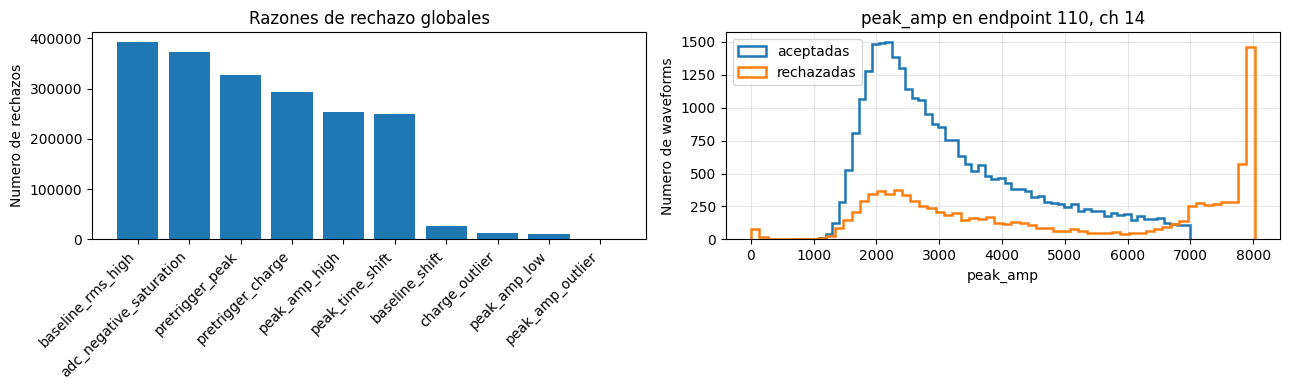

In [15]:
# Diagnosticos rapidos de los filtros de calidad

if "quality_pass_by_wf_id" not in globals() or "quality_records_by_channel" not in globals():
    raise RuntimeError(
        "Antes de ejecutar los diagnosticos ejecuta la celda: "
        "'Aplicar los filtros de calidad y crear wfset_quality'."
    )


# Cambia este canal para estudiar por que se aceptan/rechazan eventos.
target_quality_endpoint = 110
target_quality_channel = 14
metric_to_plot = "peak_amp"

# Metricas disponibles para metric_to_plot:
#   "baseline"          baseline calculada por runBasicWfAnaNP02
#   "baseline_rms"      RMS en la ventana de baseline
#   "pre_max"           maximo positivo antes de la senal
#   "pre_integral_pos"  carga positiva acumulada antes de la senal
#   "peak_tick"         tick del maximo en la ventana de senal
#   "peak_amp"          amplitud maxima en la ventana de senal
#   "charge"            integral en la ventana de carga
#   "raw_adc_min"       minimo ADC - baseline de la waveform
#   "raw_adc_max"       maximo ADC - baseline de la waveform

channel_key = (target_quality_endpoint, target_quality_channel)
records_ch = quality_records_by_channel[channel_key]
passed_ch = np.array([quality_pass_by_wf_id[rec["wf_id"]] for rec in records_ch], dtype=bool)
values_ch = np.array([rec[metric_to_plot] for rec in records_ch], dtype=float)

print(f"Canal {channel_key}: {len(records_ch)} waveforms")
print(f"  aceptadas: {np.sum(passed_ch)}")
print(f"  rechazadas: {np.sum(~passed_ch)}")

# Resumen de razones de rechazo en este canal.
reason_counts_ch = Counter()
for rec in records_ch:
    reason_counts_ch.update(quality_reasons_by_wf_id[rec["wf_id"]])

print("Razones de rechazo en este canal:")
for reason, count in reason_counts_ch.most_common():
    print(f"  {reason:22s}: {count}")

fig, axs = plt.subplots(1, 2, figsize=(13, 4))

if len(quality_reason_counts) > 0:
    reasons, counts = zip(*quality_reason_counts.most_common())
    axs[0].bar(range(len(reasons)), counts)
    axs[0].set_xticks(range(len(reasons)))
    axs[0].set_xticklabels(reasons, rotation=45, ha="right")
    axs[0].set_ylabel("Numero de rechazos")
    axs[0].set_title("Razones de rechazo globales")
else:
    axs[0].text(0.5, 0.5, "Sin rechazos", ha="center", va="center")
    axs[0].set_axis_off()

axs[1].hist(values_ch[passed_ch], bins=60, histtype="step", linewidth=1.8, label="aceptadas")
axs[1].hist(values_ch[~passed_ch], bins=60, histtype="step", linewidth=1.8, label="rechazadas")
axs[1].set_xlabel(metric_to_plot)
axs[1].set_ylabel("Numero de waveforms")
axs[1].set_title(f"{metric_to_plot} en endpoint {target_quality_endpoint}, ch {target_quality_channel}")
axs[1].legend()
axs[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
# Filtro adicional de amplitud, aplicado despues de wfset_quality

if "wfset_quality" not in globals():
    raise RuntimeError(
        "Antes del filtro adicional de amplitud ejecuta la celda: "
        "'Aplicar los filtros de calidad y crear wfset_quality'."
    )


# Este filtro conserva la idea original: pulso suficientemente grande y no saturado.
def select_amp(waveform: Waveform) -> bool:
    slice_min = slice(75,80)
    ch = waveform.channel
    ep = waveform.endpoint
    if ch == 16:
        slice_min = slice(78,83)
    if np.min(waveform.adcs[slice_min]-waveform.analyses['std'].result['baseline']) > 400:
        if np.max(waveform.adcs[60:80]-waveform.analyses['std'].result['baseline']) < 7e3:
            return True
    return False
wfset = WaveformSet.from_filtered_WaveformSet(wfset_quality, select_amp, show_progress=True)
wfch = ChannelWsGrid.clusterize_waveform_set(wfset)
wfch


  0%|          | 0/962462 [00:00<?, ?it/s]

100%|██████████| 962462/962462 [00:16<00:00, 59076.28it/s]


{110: {7: WaveformSet with 32275 waveforms runs: [43363], points_per_wf: 1024, available_channels: {43363: {110: {7}}}, record_numbers per run: run 43363: 4323 records,
  46: WaveformSet with 43486 waveforms runs: [43363], points_per_wf: 1024, available_channels: {43363: {110: {46}}}, record_numbers per run: run 43363: 4326 records,
  34: WaveformSet with 28934 waveforms runs: [43363], points_per_wf: 1024, available_channels: {43363: {110: {34}}}, record_numbers per run: run 43363: 4325 records,
  26: WaveformSet with 58181 waveforms runs: [43363], points_per_wf: 1024, available_channels: {43363: {110: {26}}}, record_numbers per run: run 43363: 4327 records,
  24: WaveformSet with 38203 waveforms runs: [43363], points_per_wf: 1024, available_channels: {43363: {110: {24}}}, record_numbers per run: run 43363: 4326 records,
  32: WaveformSet with 44669 waveforms runs: [43363], points_per_wf: 1024, available_channels: {43363: {110: {32}}}, record_numbers per run: run 43363: 4327 records,
 

# Canales a Analizar
La lista de canales a plotear es 14, 12, 37, 0, 17, 10, 16, 2, 7, 40, 6, 36, 34, 46, 24, 32, 42, 26, 22, 44, 30, 20. (orden descendente y de izq a dch)

# Visor interactivo de waveforms por canal despues del filtrado

In [17]:
# # Visor interactivo de waveforms por canal despues del filtrado

# from ipywidgets import interact, IntSlider, Dropdown
# import numpy as np
# import matplotlib.pyplot as plt

# ENDPOINT = 110

# # Canales disponibles en el endpoint 110
# channels = sorted(
#     list(set(
#         wf.channel
#         for wf in wfset.waveforms
#         if wf.endpoint == ENDPOINT
#     ))
# )

# @interact(
#     channel=Dropdown(
#         options=channels,
#         description="Channel"
#     )
# )
# def browse_channel(channel):

#     selected_wfs = [
#         wf for wf in wfset.waveforms
#         if wf.endpoint == ENDPOINT and wf.channel == channel
#     ]

#     @interact(
#         idx=IntSlider(
#             min=0,
#             max=max(0, len(selected_wfs)-1),
#             step=1,
#             value=0,
#             description="WF"
#         )
#     )
#     def show_waveform(idx):

#         wf = selected_wfs[idx]

#         baseline = wf.analyses["std"].result["baseline"]
#         y = np.asarray(wf.adcs) - baseline

#         plt.figure(figsize=(10,4))
#         plt.plot(y)
#         plt.xlabel("Tick")
#         plt.ylabel("ADC - baseline")
#         plt.title(
#             f"Endpoint {ENDPOINT} | Channel {channel} | WF {idx}"
#         )
#         plt.grid(True)
#         plt.show()

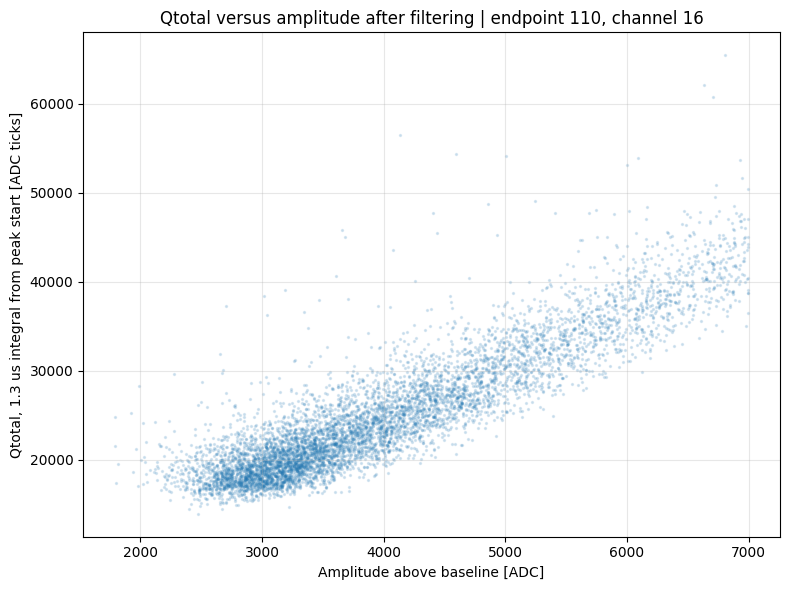

In [18]:
# Qtotal versus amplitude after filtering for one channel

if "wfset" not in globals():
    raise RuntimeError("Run the filtering cell first, so wfset exists.")

selected_endpoint = 110
selected_channel = 16
analysis_label = "std"
peak_search_window = slice(60, 110)
tick_duration_ns = 16.0
qtotal_duration_ns = 1_300.0

qtotal_ticks = int(np.round(qtotal_duration_ns / tick_duration_ns))
qtotal_values_filtered = []
amplitude_values_filtered = []

for wf in wfset.waveforms:
    if wf.endpoint != selected_endpoint or wf.channel != selected_channel:
        continue

    if analysis_label not in wf.analyses:
        raise RuntimeError(f"Waveform has no analysis '{analysis_label}'. Run runBasicWfAnaNP02 first.")

    baseline = wf.analyses[analysis_label].result["baseline"]
    y = np.asarray(wf.adcs, dtype=float) - baseline
    peak_region = y[peak_search_window]
    if len(peak_region) == 0:
        raise ValueError("Peak search window is empty for this waveform.")

    peak_tick = peak_search_window.start + int(np.argmax(peak_region))
    qtotal_start_tick = max(peak_tick - 1, 0)
    qtotal_stop_tick = min(qtotal_start_tick + qtotal_ticks, len(y))
    signal_region = y[qtotal_start_tick:qtotal_stop_tick]

    qtotal_values_filtered.append(np.sum(signal_region))
    amplitude_values_filtered.append(np.max(signal_region))

if len(qtotal_values_filtered) == 0:
    raise ValueError(f"No filtered waveforms found for endpoint {selected_endpoint}, channel {selected_channel}")

qtotal_values_filtered = np.array(qtotal_values_filtered)
amplitude_values_filtered = np.array(amplitude_values_filtered)

plt.figure(figsize=(8, 6))
plt.scatter(amplitude_values_filtered, qtotal_values_filtered, s=2, alpha=0.15, rasterized=True)
plt.xlabel("Amplitude above baseline [ADC]")
plt.ylabel("Qtotal, 1.3 us integral from peak start [ADC ticks]")
plt.title(f"Qtotal versus amplitude after filtering | endpoint {selected_endpoint}, channel {selected_channel}")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


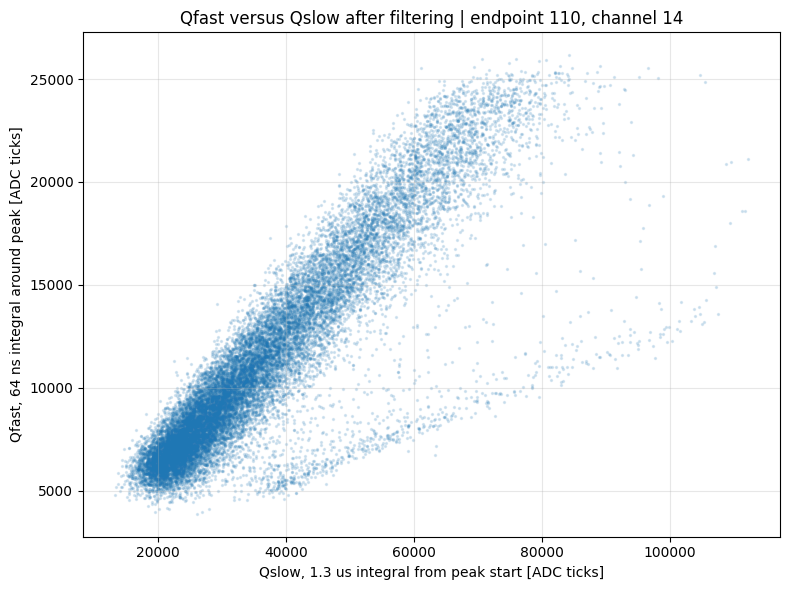

In [19]:
# Qfast versus Qslow after filtering for one channel

if "wfset" not in globals():
    raise RuntimeError("Run the filtering cell first, so wfset exists.")

selected_endpoint = 110
selected_channel = 14
analysis_label = "std"
peak_search_window = slice(60, 110)
tick_duration_ns = 16.0
qfast_duration_ns = 64.0
qtotal_duration_ns = 1_300.0

qfast_ticks = int(np.round(qfast_duration_ns / tick_duration_ns))
qtotal_ticks = int(np.round(qtotal_duration_ns / tick_duration_ns))
qfast_values_filtered = []
qslow_values_filtered = []

for wf in wfset.waveforms:
    if wf.endpoint != selected_endpoint or wf.channel != selected_channel:
        continue

    if analysis_label not in wf.analyses:
        raise RuntimeError(f"Waveform has no analysis '{analysis_label}'. Run runBasicWfAnaNP02 first.")

    baseline = wf.analyses[analysis_label].result["baseline"]
    y = np.asarray(wf.adcs, dtype=float) - baseline
    peak_region = y[peak_search_window]
    if len(peak_region) == 0:
        raise ValueError("Peak search window is empty for this waveform.")

    peak_tick = peak_search_window.start + int(np.argmax(peak_region))
    qfast_start_tick = max(peak_tick - 1, 0)
    qfast_stop_tick = min(qfast_start_tick + qfast_ticks, len(y))
    qtotal_stop_tick = min(qfast_start_tick + qtotal_ticks, len(y))

    qfast = np.sum(y[qfast_start_tick:qfast_stop_tick])
    qtotal = np.sum(y[qfast_start_tick:qtotal_stop_tick])
    qslow = qtotal

    qfast_values_filtered.append(qfast)
    qslow_values_filtered.append(qslow)

if len(qfast_values_filtered) == 0:
    raise ValueError(f"No filtered waveforms found for endpoint {selected_endpoint}, channel {selected_channel}")

qfast_values_filtered = np.array(qfast_values_filtered)
qslow_values_filtered = np.array(qslow_values_filtered)

plt.figure(figsize=(8, 6))
plt.scatter(qslow_values_filtered, qfast_values_filtered, s=2, alpha=0.15, rasterized=True)
plt.xlabel("Qslow, 1.3 us integral from peak start [ADC ticks]")
plt.ylabel("Qfast, 64 ns integral around peak [ADC ticks]")
plt.title(f"Qfast versus Qslow after filtering | endpoint {selected_endpoint}, channel {selected_channel}")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


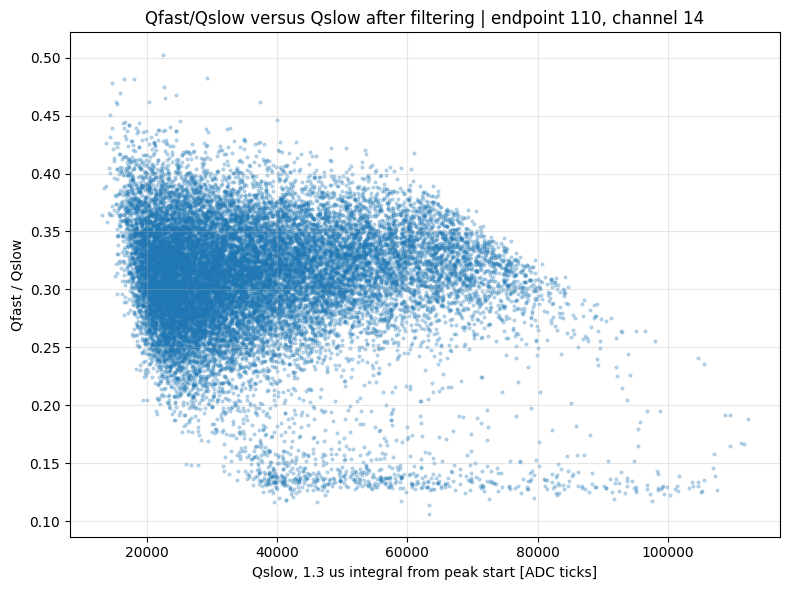

In [20]:
# Qfast/Qslow versus Qslow after filtering for one channel

if "qfast_values_filtered" not in globals() or "qslow_values_filtered" not in globals():
    raise RuntimeError("Run the Qfast versus Qslow after filtering cell first.")

qfast_over_qslow_filtered = np.divide(
    qfast_values_filtered,
    qslow_values_filtered,
    out=np.full_like(qfast_values_filtered, np.nan, dtype=float),
    where=qslow_values_filtered != 0,
)
valid_ratio_filtered = np.isfinite(qfast_over_qslow_filtered)

plt.figure(figsize=(8, 6))
plt.scatter(
    qslow_values_filtered[valid_ratio_filtered],
    qfast_over_qslow_filtered[valid_ratio_filtered],
    s=4,
    alpha=0.25,
    rasterized=True,
)
plt.xlabel("Qslow, 1.3 us integral from peak start [ADC ticks]")
plt.ylabel("Qfast / Qslow")
plt.title(f"Qfast/Qslow versus Qslow after filtering | endpoint {selected_endpoint}, channel {selected_channel}")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


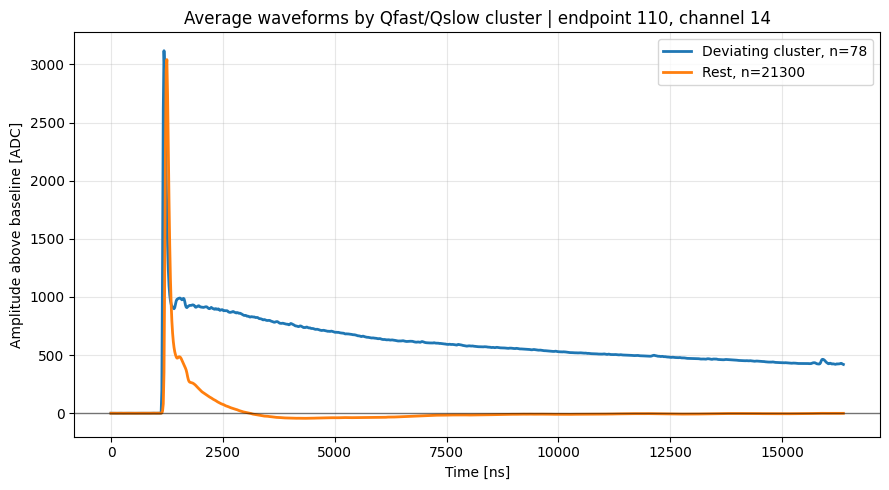

Deviating cluster: 78 waveforms
Rest: 21300 waveforms


In [21]:
# Average waveforms for the Qfast/Qslow cluster and the remaining events

if "wfset" not in globals():
    raise RuntimeError("Run the filtering cell first, so wfset exists.")

selected_endpoint = 110
selected_channel = 14
analysis_label = "std"
peak_search_window = slice(60, 110)
tick_duration_ns = 16.0
qfast_duration_ns = 64.0
qtotal_duration_ns = 1_300.0

# Parámetros definidos específicamente para el canal 14
qfast_ticks = int(np.round(qfast_duration_ns / tick_duration_ns))
qtotal_ticks = int(np.round(qtotal_duration_ns / tick_duration_ns))
deviating_qslow_range = (75_000, 175_000)
deviating_qfast_range = (0, 12_500)

pulse_shape_cluster_records = []
pulse_shape_clusters = {"deviating": [], "rest": []}
pulse_shape_corrected_wfs = {"deviating": [], "rest": []}

for wf_index, wf in enumerate(wfset.waveforms):
    if wf.endpoint != selected_endpoint or wf.channel != selected_channel:
        continue

    if analysis_label not in wf.analyses:
        raise RuntimeError(f"Waveform has no analysis '{analysis_label}'. Run runBasicWfAnaNP02 first.")

    baseline = wf.analyses[analysis_label].result["baseline"]
    y = np.asarray(wf.adcs, dtype=float) - baseline
    peak_region = y[peak_search_window]
    if len(peak_region) == 0:
        raise ValueError("Peak search window is empty for this waveform.")

    peak_tick = peak_search_window.start + int(np.argmax(peak_region))
    qfast_start_tick = max(peak_tick - 1, 0)
    qfast_stop_tick = min(qfast_start_tick + qfast_ticks, len(y))
    qtotal_stop_tick = min(qfast_start_tick + qtotal_ticks, len(y))

    qfast = float(np.sum(y[qfast_start_tick:qfast_stop_tick]))
    qslow = float(np.sum(y[qfast_start_tick:qtotal_stop_tick]))

    is_deviating = (
        deviating_qslow_range[0] <= qslow <= deviating_qslow_range[1]
        and deviating_qfast_range[0] <= qfast <= deviating_qfast_range[1]
    )
    cluster_name = "deviating" if is_deviating else "rest"

    rec = {
        "wf_index": wf_index,
        "cluster": cluster_name,
        "waveform": wf,
        "baseline": float(baseline),
        "peak_tick": int(peak_tick),
        "qfast_start_tick": int(qfast_start_tick),
        "qfast_stop_tick": int(qfast_stop_tick),
        "qtotal_stop_tick": int(qtotal_stop_tick),
        "qfast": qfast,
        "qslow": qslow,
        "qfast_over_qslow": qfast / qslow if qslow != 0 else np.nan,
    }
    pulse_shape_cluster_records.append(rec)
    pulse_shape_clusters[cluster_name].append(rec)
    pulse_shape_corrected_wfs[cluster_name].append(y)

if len(pulse_shape_cluster_records) == 0:
    raise ValueError(f"No filtered waveforms found for endpoint {selected_endpoint}, channel {selected_channel}")

pulse_shape_mean_wfs = {}
for cluster_name, corrected_wfs in pulse_shape_corrected_wfs.items():
    if len(corrected_wfs) == 0:
        raise ValueError(f"No waveforms found in cluster '{cluster_name}'. Check the Qfast/Qslow ranges.")
    pulse_shape_mean_wfs[cluster_name] = np.mean(np.vstack(corrected_wfs), axis=0)

time_ns = np.arange(len(pulse_shape_mean_wfs["rest"])) * tick_duration_ns

plt.figure(figsize=(9, 5))
plt.plot(
    time_ns,
    pulse_shape_mean_wfs["deviating"],
    label=f"Deviating cluster, n={len(pulse_shape_clusters['deviating'])}",
    linewidth=2,
)
plt.plot(
    time_ns,
    pulse_shape_mean_wfs["rest"],
    label=f"Rest, n={len(pulse_shape_clusters['rest'])}",
    linewidth=2,
)
plt.axhline(0, color="black", linewidth=1, alpha=0.5)
plt.xlabel("Time [ns]")
plt.ylabel("Amplitude above baseline [ADC]")
plt.title(f"Average waveforms by Qfast/Qslow cluster | endpoint {selected_endpoint}, channel {selected_channel}")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Deviating cluster: {len(pulse_shape_clusters['deviating'])} waveforms")
print(f"Rest: {len(pulse_shape_clusters['rest'])} waveforms")


# Viewer for individual waveforms in each Qfast/Qslow cluster

In [22]:
# # Viewer for individual waveforms in each Qfast/Qslow cluster

# from ipywidgets import interact, IntSlider, Dropdown

# if "pulse_shape_clusters" not in globals():
#     raise RuntimeError("Run the average-waveform cluster cell first.")

# max_cluster_size = max(len(records) for records in pulse_shape_clusters.values())

# def plot_pulse_shape_cluster_event(cluster_name, event_index):
#     records = pulse_shape_clusters[cluster_name]
#     if len(records) == 0:
#         raise ValueError(f"No waveforms found in cluster '{cluster_name}'.")

#     event_index = min(event_index, len(records) - 1)
#     rec = records[event_index]
#     wf = rec["waveform"]
#     y = np.asarray(wf.adcs, dtype=float) - rec["baseline"]
#     time_ns = np.arange(len(y)) * tick_duration_ns

#     plt.figure(figsize=(10, 4.5))
#     plt.plot(time_ns, y, linewidth=1.2)
#     plt.axhline(0, color="black", linewidth=1, alpha=0.5)
#     plt.axvline(rec["peak_tick"] * tick_duration_ns, color="tab:red", linestyle="--", linewidth=1.2, label="Peak tick")
#     plt.axvspan(
#         rec["qfast_start_tick"] * tick_duration_ns,
#         rec["qfast_stop_tick"] * tick_duration_ns,
#         color="tab:orange",
#         alpha=0.25,
#         label="Qfast window",
#     )
#     plt.axvspan(
#         rec["qfast_start_tick"] * tick_duration_ns,
#         rec["qtotal_stop_tick"] * tick_duration_ns,
#         color="tab:blue",
#         alpha=0.08,
#         label="Qslow window",
#     )
#     plt.xlabel("Time [ns]")
#     plt.ylabel("Amplitude above baseline [ADC]")
#     plt.title(
#         f"{cluster_name} event {event_index}/{len(records)-1} | "
#         f"Qfast={rec['qfast']:.1f}, Qslow={rec['qslow']:.1f}, Qfast/Qslow={rec['qfast_over_qslow']:.3f}"
#     )
#     plt.legend(loc="best")
#     plt.grid(alpha=0.3)
#     plt.tight_layout()
#     plt.show()

# interact(
#     plot_pulse_shape_cluster_event,
#     cluster_name=Dropdown(options=["deviating", "rest"], value="deviating", description="Cluster"),
#     event_index=IntSlider(value=0, min=0, max=max_cluster_size - 1, step=1, description="Event"),
# )


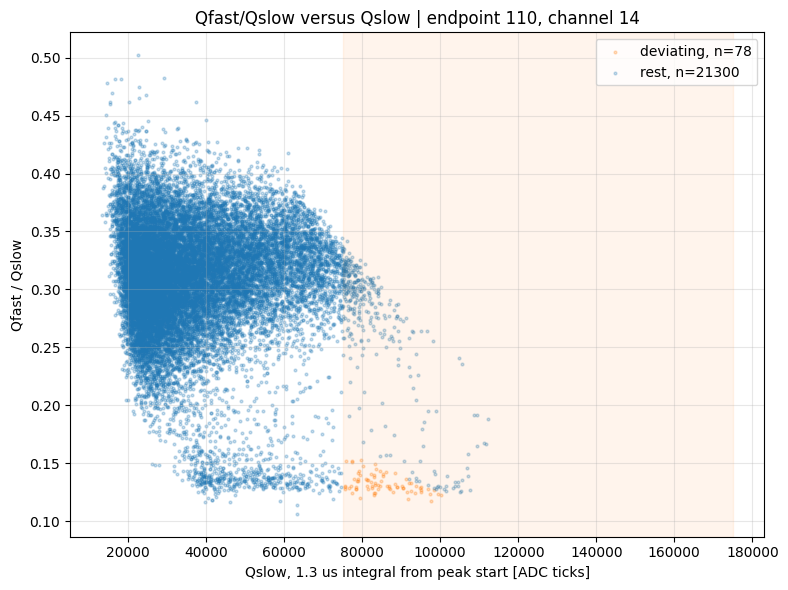

In [23]:
# Qfast/Qslow versus Qslow for the selected channel

if "pulse_shape_cluster_records" not in globals():
    raise RuntimeError("Run the average-waveform cluster cell first.")

qslow_cluster_values = np.array([rec["qslow"] for rec in pulse_shape_cluster_records])
qfast_over_qslow_values = np.array([rec["qfast_over_qslow"] for rec in pulse_shape_cluster_records])
cluster_names = np.array([rec["cluster"] for rec in pulse_shape_cluster_records])
valid_ratio = np.isfinite(qfast_over_qslow_values)

plt.figure(figsize=(8, 6))
for cluster_name, color in [("deviating", "tab:orange"), ("rest", "tab:blue")]:
    mask = valid_ratio & (cluster_names == cluster_name)
    plt.scatter(
        qslow_cluster_values[mask],
        qfast_over_qslow_values[mask],
        s=4,
        alpha=0.25,
        color=color,
        label=f"{cluster_name}, n={np.sum(mask)}",
        rasterized=True,
    )

plt.axvspan(deviating_qslow_range[0], deviating_qslow_range[1], color="tab:orange", alpha=0.08)
plt.xlabel("Qslow, 1.3 us integral from peak start [ADC ticks]")
plt.ylabel("Qfast / Qslow")
plt.title(f"Qfast/Qslow versus Qslow | endpoint {selected_endpoint}, channel {selected_channel}")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [24]:
wftmp = wfset

# plot_detectors(wfset, detector, **argsheat)


In [ ]:
# Calcular la waveform promedio por canal y ajustar con deconvolución (Fit)

from waffles.utils.numerical_utils import average_wf_ch
from waffles.utils.deconvolution.DeconvFitter import DeconvFitter
import math

average_wvf = {}

def pmt_average_and_fit(wfset: WaveformSet):
    denoiser = Denoise()
    # deconv = DeconvFitter()
    deconv = DeconvFitter(scinttype='larxe')    # Usar el modelo LArXe para incluir la componente intermedia td en el ajuste.

    ep = wfset.waveforms[0].endpoint
    ch = wfset.waveforms[0].channel

    # wfm = average_wf_ch(wfset)
    # wfm = wfm - np.mean(wfm[:50])

    # --- Restar baseline waveform por waveform antes de promediar (para eliminar ruido)
    # corrected_wfs = []
    # for wf in wfset.waveforms:
    #     baseline = wf.analyses["std"].result["baseline"]
    #     corrected_wfs.append(wf.adcs - baseline)

    # wfm = np.mean(corrected_wfs, axis=0)

    # # Aplicar denoising
    # wfm = denoiser.apply_denoise(wfm, filter=2)

    # ---

    # --- Restar baseline waveform por waveform y alinear pulsos antes de promediar

    # Esta función desplaza una waveform en el eje temporal
    def shift_waveform(y, shift, fill_value=np.nan):
        y_shifted = np.full_like(y, fill_value, dtype=float)

        if shift > 0:
            y_shifted[shift:] = y[:-shift]
        elif shift < 0:
            y_shifted[:shift] = y[-shift:]
        else:
            y_shifted[:] = y

        return y_shifted


    # Restar baseline waveform por waveform y calcular el tick del maximo
    corrected_wfs = []
    peak_ticks = []

    search_window = slice(60, 100)

    for wf in wfset.waveforms:
        baseline = wf.analyses["std"].result["baseline"]
        y = wf.adcs - baseline

        corrected_wfs.append(y)

        peak_tick = np.argmax(y[search_window]) + search_window.start
        peak_ticks.append(peak_tick)

    peak_ticks = np.array(peak_ticks)

    # Usar como referencia el tick mediano del maximo de este canal
    reference_tick = int(np.median(peak_ticks))

    # Alinear las waveforms
    aligned_wfs = []

    for y, peak_tick in zip(corrected_wfs, peak_ticks):
        shift = reference_tick - peak_tick
        aligned_wfs.append(shift_waveform(y, shift))

    wfm = np.nanmean(aligned_wfs, axis=0)

    # Aplicar denoising
    wfm = denoiser.apply_denoise(wfm, filter=2)

    # ---

    deconv.deconvolved = wfm
    average_wvf[(ep, ch)] = wfm

    # oneexp = True if getModuleName(ep,ch) == "P35" else False
    oneexp=False
    deconv.fit(
        oneexp=oneexp,
        fit_limits_ns=[None, 10000],
        fixed_tau_fast_ns=6.0,  # Fijar tau_fast, t1, a 6 ns durante todo el ajuste.
        # fixed_tau_fast_ns=None, # Dejar tau_fast como parametro libre
    )

    nticks = len(deconv.deconvolved)
    times = np.linspace(0, nticks*16, nticks, endpoint=False)

    plt.plot(times, deconv.deconvolved, '-', lw=2, color='k', label='data')

    if hasattr(deconv, 'fit_results') and len(deconv.fit_results) > 0:
        plt.plot(deconv.times, deconv.model(deconv.times, *deconv.fit_results), color='r', zorder=100, label='Fit Model')
        
        fit_info = [
            f"$\\chi^2$/$n_\\mathrm{{dof}}$ = {deconv.m.fval:.2f} / {deconv.m.ndof:.0f} = {deconv.m.fmin.reduced_chi2:.2f}",
        ]

        mapnames = {
            'A': 'Norm.',
            'fp': 'A_\\text{fast}',
            'fs': 'A_\\text{slow}',
            't1': '\\tau_\\text{fast}',
            't3': '\\tau_\\text{slow}',
            'td': '\\tau_\\text{inter}',  # td es la constante de tiempo intermedia en el modelo LArXe
            't0': 't_\\text{0}',
            'sigma': '\\sigma',
        }

        param_lines = {}
        param_order = []
        for p, v, e in zip(deconv.m.parameters, deconv.m.values, deconv.m.errors):
            if p in mapnames:
                param_lines[p] = f"${mapnames[p]}$ = ${v:.3f} \\pm {e:.3f}$"
                param_order.append(p)

        # Invertir posicion de tau_slow (t3) y tau_inter (td) en el display
        if 't3' in param_order and 'td' in param_order:
            i_slow, i_inter = param_order.index('t3'), param_order.index('td')
            param_order[i_slow], param_order[i_inter] = param_order[i_inter], param_order[i_slow]

        for p in param_order:
            fit_info.append(param_lines[p])

        plt.plot([], [], ' ', label='\n'.join(fit_info))

    plt.title(f"{getModuleName(ep,ch)}: {ep}-{ch}")

    plt.yscale('symlog', linthresh=10)
    plt.ylim(-10, np.max(wfm)*1.5)

    # Así estaba previamente
    #plt.yscale('log')
    #plt.ylim(0.1, np.max(wfm)*1.5)

    plt.legend(fontsize=8)
    plt.ylabel('Amplitude [ADC]')
    plt.xlabel('Time [ns]')
    plt.xlim(0, 6000)
    # plt.savefig('out.png')


In [26]:
# Plots antiguos

# fig, axs = matplotlib_plot_WaveformSetGrid(wftmp, detector=group1, plot_function=pmt_average_and_fit, figsize=(20,20))
# plt.tight_layout()
# plt.savefig('pmts1.png')
# plt.show()

# fig, axs = matplotlib_plot_WaveformSetGrid(wftmp, detector=group2, plot_function=pmt_average_and_fit, figsize=(20,20))
# plt.tight_layout()
# plt.savefig('pmts2.png')
# plt.show()

# Canales a Analizar
La lista de canales a plotear es 14, 12, 37, 0, 17, 10, 16, 2, 7, 40, 6, 36, 34, 46, 24, 32, 42, 26, 22, 44, 30, 20. (orden descendente y de izq a dch)

In [ ]:
# PMT layout para las waveforms promedio y sus fits

import matplotlib.patches as mpatches

endpoint = 110

layout = [
    [None,            ("PMT 15", 14), ("PMT 41", 12), None],
    [("PMT 12", 37), ("PMT 5", 0),   ("PMT 38", 17), ("PMT 31", 10)],
    [("PMT 40", None), ("PMT 13", None), ("PMT 35", 16), ("PMT 37", 2)],
    [("PMT 29", 7),  ("PMT 34", 40), ("PMT 7", 6),   ("PMT 28", 36)],
    [("PMT 32", 34), ("PMT 17", 46), ("PMT 25", 24), ("PMT 26", 32)],
    [("PMT 16", 42), ("PMT 6", 26),  ("PMT 14", 22), ("PMT 19", 44)],
    [None,            ("PMT 20", 30), ("PMT 21", 20), None],
]

wls_by_channel = {
    14: "PEN",   12: "PEN",   37: "TPB",   0: "TPB",
    17: "PEN",   10: "PEN",   16: "PEN+Q", 2: "PEN",
    7: "PEN",    40: "PEN",   6: "PEN",    36: "PEN",
    34: "PEN",   46: "PEN",   24: "PEN",   32: "PEN",
    42: "TPB",   26: "TPB",   22: "TPB",   44: "TPB",
    30: "PEN",   20: "CLEAR",
}

# (reason_label, background_color, text_color)
excluded_channels = {
    10: ("Undershoot", "#FFF3CD", "#7D4E00"),
    14: ("Undershoot", "#FFF3CD", "#7D4E00"),
    36: ("Undershoot", "#FFF3CD", "#7D4E00"),
    0:  ("Saturation", "#CCE5FF", "#003D80"),
    6:  ("Saturation", "#CCE5FF", "#003D80"),
    30: ("Saturation", "#CCE5FF", "#003D80"),
    32: ("Saturation", "#CCE5FF", "#003D80"),
    42: ("Bad signal", "#F8D7DA", "#721C24"),
    44: ("Bad signal", "#F8D7DA", "#721C24"),
}

fig, axs = plt.subplots(nrows=7, ncols=4, figsize=(26, 40), squeeze=False)

for row_idx, row in enumerate(layout):
    for col_idx, item in enumerate(row):
        ax = axs[row_idx, col_idx]

        if item is None:
            ax.axis("off")
            continue

        pmt_label, channel = item

        if channel is None:
            ax.set_facecolor("#fff0f0")
            ax.text(
                0.5, 0.5,
                f"{pmt_label}\nNot working",
                ha="center", va="center",
                color="red", fontweight="bold",
                transform=ax.transAxes,
            )
            ax.set_xticks([])
            ax.set_yticks([])
            continue

        wls = wls_by_channel.get(channel, "?")

        if channel in excluded_channels:
            reason, bg_color, txt_color = excluded_channels[channel]
            ax.set_facecolor(bg_color)
            ax.text(
                0.5, 0.5,
                f"{pmt_label}  |  Ch {channel}\nWLS: {wls}\n{reason}",
                ha="center", va="center",
                color=txt_color, fontweight="bold", fontsize=11,
                transform=ax.transAxes,
            )
            ax.set_xticks([])
            ax.set_yticks([])
            continue

        def select_this_channel(wf, endpoint=endpoint, channel=channel):
            return wf.endpoint == endpoint and wf.channel == channel

        wfset_ch = WaveformSet.from_filtered_WaveformSet(
            wfset,
            select_this_channel,
            show_progress=False,
        )

        plt.sca(ax)

        if len(wfset_ch.waveforms) == 0:
            ax.text(
                0.5, 0.5,
                f"{pmt_label}\nCh {channel} | WLS: {wls}\nNo waveforms",
                ha="center", va="center",
                color="red", fontweight="bold",
                transform=ax.transAxes,
            )
            ax.set_xticks([])
            ax.set_yticks([])
        else:
            pmt_average_and_fit(wfset_ch)
            ax.set_title(f"{pmt_label} | Ch {channel} | WLS: {wls}", fontsize=9)

# Leyenda de canales excluidos
legend_patches = [
    mpatches.Patch(facecolor="#FFF3CD", edgecolor="#7D4E00", label="Undershoot  (ch 10, 14, 36)"),
    mpatches.Patch(facecolor="#CCE5FF", edgecolor="#003D80", label="Saturation  (ch 0, 6, 30, 32)"),
    mpatches.Patch(facecolor="#F8D7DA", edgecolor="#721C24", label="Bad signal  (ch 42, 44)"),
]
fig.legend(handles=legend_patches, loc="upper center", ncol=3, fontsize=12,
           bbox_to_anchor=(0.5, 0.985), framealpha=0.95)

fig.subplots_adjust(hspace=0.5, wspace=0.35, top=0.96, bottom=0.04, left=0.05, right=0.98)
plt.savefig("pmts_custom_layout.png", dpi=150)
plt.show()
